Dataset : 5212 echantillons,  6 features  →  7 parametres theta
Classes : 0 (non-productif) = 3425  |  1 (productif) = 1787

=== Gradient Descente ===
  iter     0  |  cout J = 0.6737
  iter    50  |  cout J = 0.3803
  iter   100  |  cout J = 0.3162
  iter   150  |  cout J = 0.2860
  iter   200  |  cout J = 0.2679
  iter   250  |  cout J = 0.2558
  iter   300  |  cout J = 0.2469
  iter   350  |  cout J = 0.2402
  iter   400  |  cout J = 0.2349
  iter   450  |  cout J = 0.2307
  iter   500  |  cout J = 0.2271
  iter   550  |  cout J = 0.2241
  iter   600  |  cout J = 0.2216
  iter   650  |  cout J = 0.2194
  iter   700  |  cout J = 0.2175
  iter   750  |  cout J = 0.2159
  iter   800  |  cout J = 0.2144
  iter   850  |  cout J = 0.2131
  iter   900  |  cout J = 0.2120
  iter   950  |  cout J = 0.2109

Theta final : [-1.9683 -0.2228 -2.0439  3.0907  0.9933 -0.2896  0.1942]
Cout final  : 0.2100



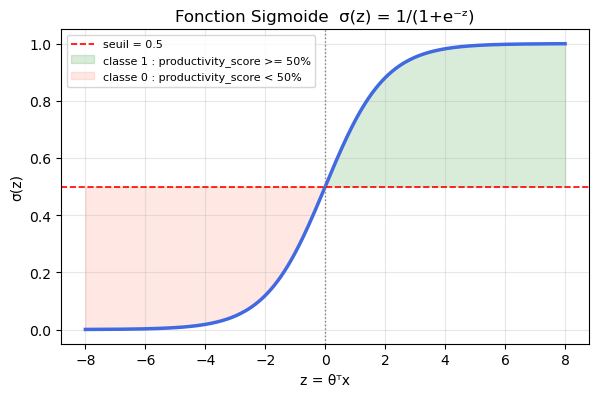

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ============================================================
# 0. PREPARATION DES DONNEES
# ============================================================
df = pd.read_csv("social_media_productivity_6000.csv")

# On garde les colonnes numeriques + on drop les NaN
features = ['daily_screen_time', 'social_media_hours', 'study_hours',
            'sleep_hours', 'notifications_per_day', 'focus_score']

df = df[features + ['productivity_score']].dropna()

# Target binaire : 1 si productive (score >= 50), 0 sinon
df['productive'] = (df['productivity_score'] >= 50).astype(int)

X_raw = df[features].values   # (n, 6)
y     = df['productive'].values  # (n,)

# Ajouter le biais (colonne de 1)
ones  = np.ones((X_norm.shape[0], 1))
X     = np.hstack([ones, X_norm])   # (n, 7)  — colonne 0 = biais

n, p = X.shape   # n echantillons, p parametres (theta_0 ... theta_6)
print(f"Dataset : {n} echantillons,  {p-1} features  →  {p} parametres theta")
print(f"Classes : 0 (non-productif) = {(y==0).sum()}  |  1 (productif) = {(y==1).sum()}\n")


# ============================================================
# 1. MODELE — h(x) = sigma(theta^T * x)
# ============================================================
def sigmoid(z):
    
    #sigma(z) = 1 / (1 + e^{-z})
    #Retourne une probabilite entre 0 et 1.
    
    return 1 / (1 + np.exp(-z))

def predict_proba(X, theta):
    
    #h_theta(x) = sigma(theta^T * x)
    #Retourne les probabilites P(y=1 | x ; theta)
    z = np.dot(X, theta)         # produit matriciel  (n,)
    return sigmoid(z)


# ============================================================
# 2. FONCTION DE COUT — Log Loss
# ============================================================
def cost(X, y, theta):
    
   # J(theta) = -1/m * sum[ y*log(h) + (1-y)*log(1-h) ]
    m = len(y)
    h = predict_proba(X, theta)
    # clip pour eviter log(0)
    h = np.clip(h, 1e-9, 1 - 1e-9)
    # on va utilise la fonction algorithme car est une fct monotone et positive
    J = -1/m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return J


# ============================================================
# 3. GRADIENT
# ============================================================
def gradient(X, y, theta):
    
    #dJ/d(theta) = 1/n * X^T * (h - y)
    #Vecteur de taille (p,)
    m = len(y)
    h = predict_proba(X, theta)
    ### la direction de l'erreur dnas l'espace de parametre
    grad = np.dot(X.T, (h - y)) / m
    return grad


# ============================================================
# 4. GRADIENT DESCENTE
# ============================================================
def gradient_descent(X, y, alpha=0.1, n_iter=1000):
    
    #theta = theta - alpha * gradient
    #Parametres :
        #alpha  : learning rate
        #n_iter : nombre d iterations
    #Retourne :
        #theta  : parametres optimises
        #history: historique du cout a chaque iteration
    
    theta   = np.zeros(X.shape[1])   # initialisation a 0
    history = []

    for i in range(n_iter):
        grad  = gradient(X, y, theta)
        theta = theta - alpha * grad

        if i % 50 == 0:
            J = cost(X, y, theta)
            history.append(J)
            print(f"  iter {i:5d}  |  cout J = {J:.4f}")

    return theta, history

print("=== Gradient Descente ===")
theta_opt, history = gradient_descent(X, y, alpha=0.1, n_iter=1000)

print(f"\nTheta final : {theta_opt.round(4)}")
print(f"Cout final  : {cost(X, y, theta_opt):.4f}\n")

# ============================================================
# 5. GRAPHES
# ============================================================
fig = plt.figure(figsize=(16, 10))
# ---  Courbe Sigmoide ---
ax1 = fig.add_subplot(gs[0, 0])
z_vals = np.linspace(-8, 8, 300)
ax1.plot(z_vals, sigmoid(z_vals), color='royalblue', linewidth=2.5)
ax1.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='seuil = 0.5')
ax1.axvline(0,   color='gray', linestyle=':', linewidth=1)
ax1.fill_between(z_vals, sigmoid(z_vals), 0.5,
                 where=(z_vals > 0), alpha=0.15, color='green', label='classe 1 : productivity_score >= 50%')
ax1.fill_between(z_vals, sigmoid(z_vals), 0.5,
                 where=(z_vals < 0), alpha=0.15, color='tomato', label='classe 0 : productivity_score < 50%')
ax1.set_title("Fonction Sigmoide  σ(z) = 1/(1+e⁻ᶻ)")
ax1.set_xlabel("z = θᵀx")
ax1.set_ylabel("σ(z)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
plt.show()

